In [3]:
import pandas as pd
import numpy as np
import json
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 110
pd.set_option('display.max_columns', None)

path_US = "../data/USvideos.csv"
df = pd.read_csv(path_US, encoding='utf-8')
print(f"Xam dataset: {df.shape[0]:,} sətir, {df.shape[1]} sütun")
path_US_category_id = "../data/US_category_id.json"
with open(path_US_category_id) as f:
    cat_json = json.load(f)

category_map = {int(item['id']): item['snippet']['title'] for item in cat_json['items']}
df['category_name'] = df['category_id'].map(category_map)

print(f"Unikal kateqoriya sayı: {df['category_name'].nunique()}")
print(f"Map edilməyən kateqoriya sətri: {df['category_name'].isna().sum()}")

df[['video_id', 'category_id', 'category_name']].head()

Xam dataset: 40,949 sətir, 16 sütun
Unikal kateqoriya sayı: 16
Map edilməyən kateqoriya sətri: 0


,video_id,category_id,category_name
0,2kyS6SvSYSE,22,People & Blogs
1,1ZAPwfrtAFY,24,Entertainment
2,5qpjK5DgCt4,23,Comedy
3,puqaWrEC7tY,24,Entertainment
4,d380meD0W0M,24,Entertainment


In [4]:
df['trending_date'] = pd.to_datetime(df['trending_date'], format='%y.%d.%m')
df['publish_time'] = pd.to_datetime(df['publish_time'])
df['engagement_rate'] = (df['likes'] + df['dislikes'] + df['comment_count']) / df['views'] * 100
df['like_rate'] = df['likes'] / df['views'] * 100
df['dislike_rate'] = df['dislikes'] / df['views'] * 100
df['days_to_trend'] = (
    df['trending_date'] - df['publish_time'].dt.tz_localize(None).dt.normalize()
).dt.days
df[['video_id', 'views', 'likes', 'dislikes', 'comment_count',
    'engagement_rate', 'like_rate', 'days_to_trend']].head()


,video_id,views,likes,dislikes,comment_count,engagement_rate,like_rate,days_to_trend
0,2kyS6SvSYSE,748374,57527,2966,15954,10.215080,7.686932,1
1,1ZAPwfrtAFY,2418783,97185,6146,12703,4.797206,4.017930,1
2,5qpjK5DgCt4,3191434,146033,5339,8181,4.999414,4.575780,2
3,puqaWrEC7tY,343168,10172,666,2146,3.783570,2.964146,1
4,d380meD0W0M,2095731,132235,1989,17518,7.240528,6.309732,2


In [5]:
print(f"Dedup-dan əvvəl: {len(df):,} sətir")
df_dedup = df.sort_values('trending_date').drop_duplicates(subset='video_id', keep='first').copy()
print(f"Dedup-dan sonra : {len(df_dedup):,} sətir")
print(f"Unikal video sayı: {df_dedup['video_id'].nunique():,}")


Dedup-dan əvvəl: 40,949 sətir
Dedup-dan sonra : 6,351 sətir
Unikal video sayı: 6,351


In [6]:
corr_cols = ['views', 'likes', 'dislikes', 'comment_count', 'engagement_rate', 'days_to_trend']
corr_matrix = df_dedup[corr_cols].corr(method='pearson')
corr_matrix.round(3)


,views,likes,dislikes,comment_count,engagement_rate,days_to_trend
views,1.000,0.761,0.396,0.600,0.057,-0.035
likes,0.761,1.000,0.360,0.806,0.319,-0.029
dislikes,0.396,0.360,1.000,0.680,0.097,-0.011
comment_count,0.600,0.806,0.680,1.000,0.258,-0.020
engagement_rate,0.057,0.319,0.097,0.258,1.000,-0.104
days_to_trend,-0.035,-0.029,-0.011,-0.020,-0.104,1.000


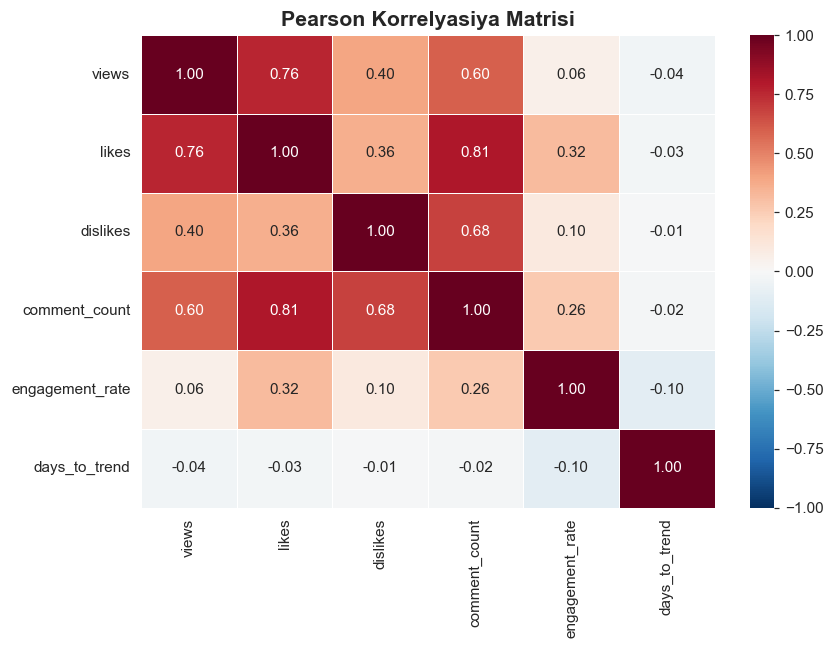

In [7]:
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            linewidths=0.5, vmin=-1, vmax=1, ax=ax)
ax.set_title('Pearson Korrelyasiya Matrisi', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()


In [8]:
category_bench = df_dedup.groupby('category_name').agg(
    Avg_Views=('views', 'mean'),
    Avg_Engagement_Rate=('engagement_rate', 'mean'),
    Avg_Like_Rate=('like_rate', 'mean'),
    Video_Count=('views', 'count')
).sort_values('Avg_Engagement_Rate', ascending=False)
category_bench.round(2)


,Avg_Views,Avg_Engagement_Rate,Avg_Like_Rate,Video_Count
category_name,,,,
Music,1387621.18,8.23,7.40,799
Howto & Style,473138.93,5.97,5.14,595
Comedy,772954.61,5.69,4.97,547
People & Blogs,712767.50,5.51,4.70,498
Gaming,1211843.80,5.48,4.38,103
Pets & Animals,280104.36,5.12,4.50,138
Education,351979.46,4.85,4.18,250
Nonprofits & Activism,1025216.57,4.83,3.74,14
Science & Technology,584322.49,4.23,3.58,380


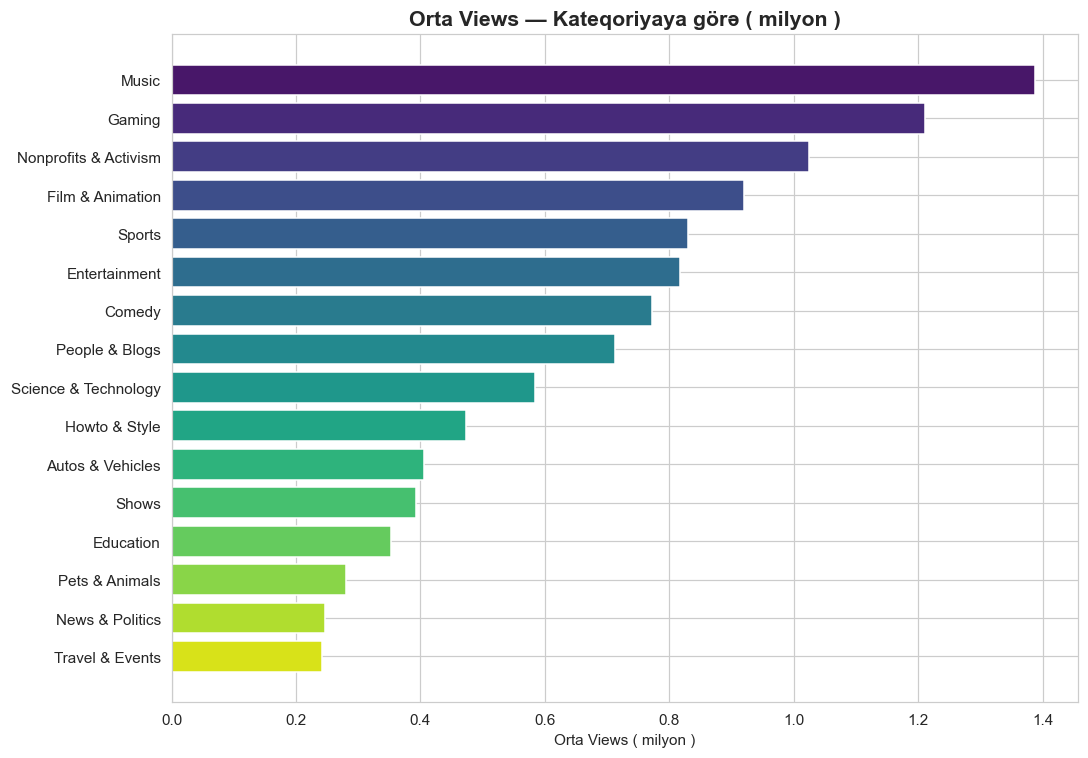

In [10]:
views_sorted = category_bench.sort_values('Avg_Views', ascending=False)
fig, ax = plt.subplots(figsize=(10, 7))
colors = sns.color_palette('viridis', len(views_sorted))
ax.barh(views_sorted.index[::-1], views_sorted['Avg_Views'][::-1] / 1e6, color=colors[::-1])
ax.set_title('Orta Views — Kateqoriyaya görə ( milyon )', fontsize=14, fontweight='bold')
ax.set_xlabel('Orta Views ( milyon )')
plt.tight_layout()
plt.savefig('avg_views_by_category.png', dpi=150, bbox_inches='tight')
plt.show()


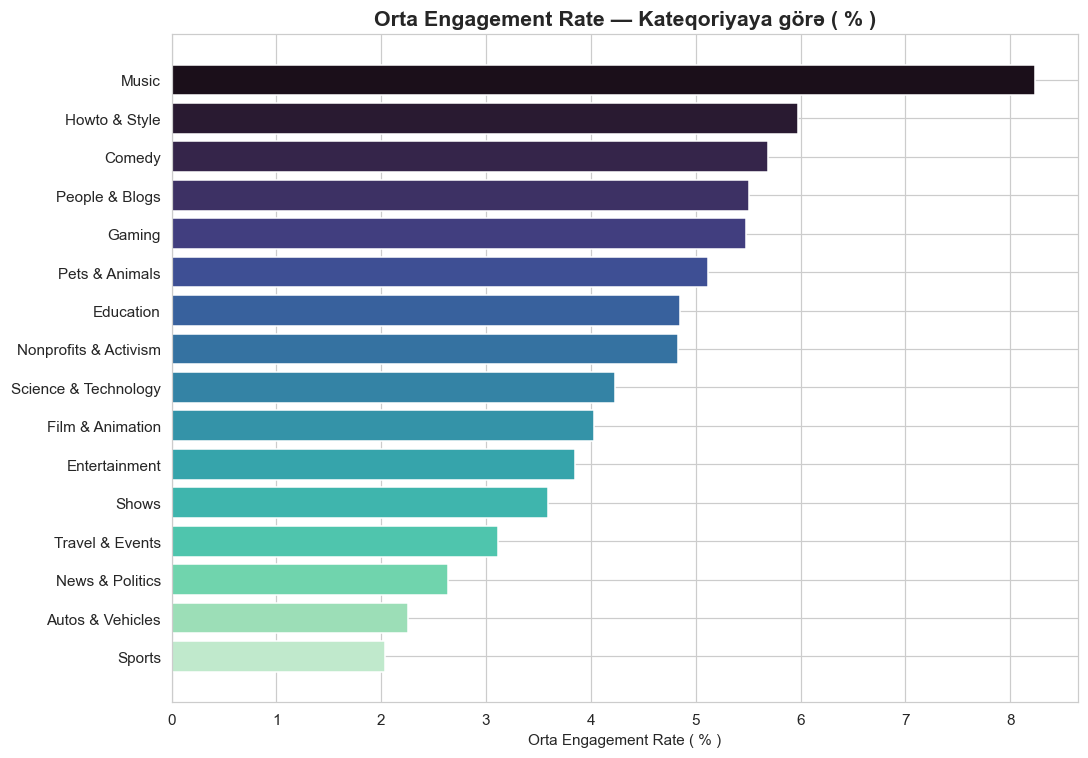

In [11]:
fig, ax = plt.subplots(figsize=(10, 7))
colors = sns.color_palette('mako', len(category_bench))
ax.barh(category_bench.index[::-1], category_bench['Avg_Engagement_Rate'][::-1], color=colors[::-1])
ax.set_title('Orta Engagement Rate — Kateqoriyaya görə ( % )', fontsize=14, fontweight='bold')
ax.set_xlabel('Orta Engagement Rate ( % )')
plt.tight_layout()
plt.savefig('avg_engagement_by_category.png', dpi=150, bbox_inches='tight')
plt.show()


In [12]:
df_dedup['publish_weekday'] = df_dedup['publish_time'].dt.day_name()
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
weekday_summary = df_dedup.groupby('publish_weekday').agg(
    Avg_Views=('views', 'mean'),
    Avg_Engagement=('engagement_rate', 'mean'),
    Video_Count=('views', 'count')
).reindex(day_order)
weekday_summary.round(2)


,Avg_Views,Avg_Engagement,Video_Count
publish_weekday,,,
Monday,750340.86,4.38,985
Tuesday,722556.56,4.57,1061
Wednesday,677738.52,4.76,1097
Thursday,713014.40,5.02,1055
Friday,894334.04,5.24,1047
Saturday,726031.16,4.88,547
Sunday,859492.58,4.32,559


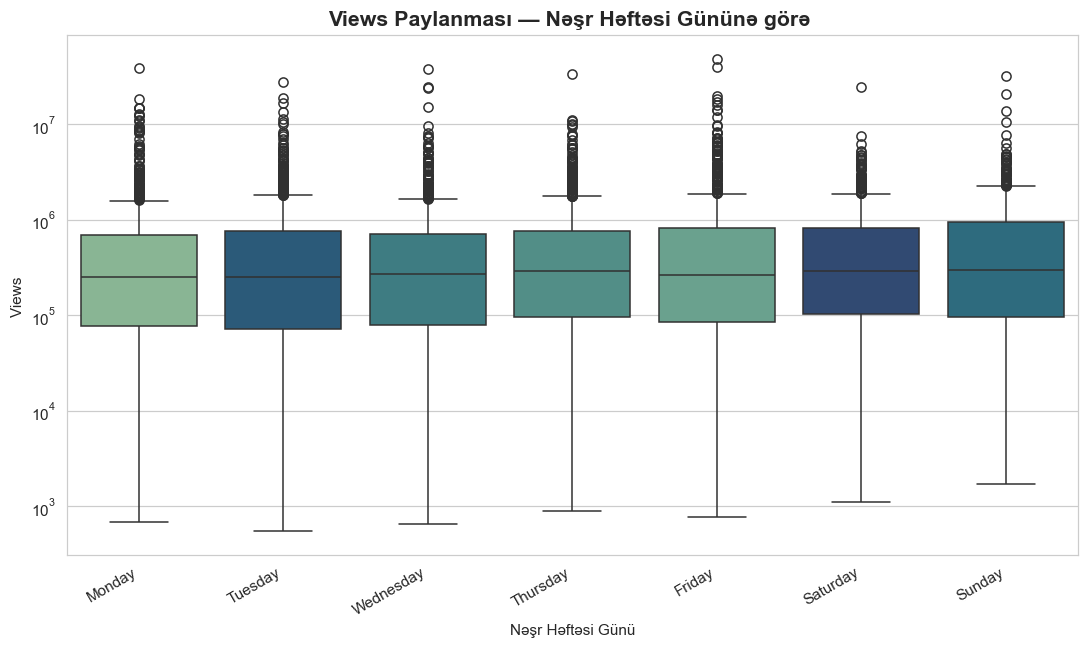

In [13]:
fig, ax = plt.subplots(figsize=(10, 6))
sns.boxplot(data=df_dedup, x='publish_weekday', y='views', order=day_order,
            hue='publish_weekday', palette='crest', legend=False, ax=ax)
ax.set_yscale('log')
ax.set_title('Views Paylanması — Nəşr Həftəsi Gününə görə ', fontsize=14, fontweight='bold')
ax.set_xlabel('Nəşr Həftəsi Günü')
ax.set_ylabel('Views ')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig('views_by_publish_weekday.png', dpi=150, bbox_inches='tight')
plt.show()


In [14]:
df_dedup['trending_weekday'] = df_dedup['trending_date'].dt.day_name()
trending_engagement = df_dedup.groupby('trending_weekday')['engagement_rate'].mean().reindex(day_order)
trending_engagement.round(3)


trending_weekday
Monday       3.979
Tuesday      4.288
Wednesday    4.942
Thursday     4.955
Friday       4.990
Saturday     5.036
Sunday       5.046
Name: engagement_rate, dtype: float64

In [15]:
top10 = df_dedup.sort_values('views', ascending=False).head(10)[
    ['title', 'category_name', 'views', 'days_to_trend', 'engagement_rate']
]
top10


,title,category_name,views,days_to_trend,engagement_rate
23824,Maluma - El Préstamo (Official Video),Music,48431654,6,1.425787
35550,BTS (방탄소년단) 'FAKE LOVE' Official MV,Music,39349927,1,11.804553
28605,TWICE What is Love? M/V,Music,38873543,5,3.639059
3200,Marvel Studios' Avengers: Infinity War Officia...,Entertainment,37736281,1,5.297557
70,Ed Sheeran - Perfect (Official Music Video),Music,33523622,5,5.191184
33351,Childish Gambino - This Is America (Official V...,Music,31648454,2,5.075682
30750,VENOM - Official Trailer (HD),Entertainment,27973210,1,3.480723
4600,YouTube Rewind: The Shape of 2017 | #YouTubeRe...,Entertainment,24782158,1,8.454518
28624,Drake - Nice For What,Music,24421448,7,2.870477
38161,Sanju | Official Trailer | Ranbir Kapoor | Raj...,Entertainment,23758250,2,2.735273


In [16]:
df_dedup['tags_count'] = df_dedup['tags'].apply(
    lambda x: 0 if x == '[none]' else len(str(x).split('|'))
)
tags_corr = df_dedup['tags_count'].corr(df_dedup['views'])
print(f"Tags sayı — views korrelyasiyası: r = {tags_corr:.3f}")


Tags sayı — views korrelyasiyası: r = 0.042


In [17]:
views_q75, views_q25 = df_dedup['views'].quantile([0.75, 0.25])
eng_q75, eng_q25 = df_dedup['engagement_rate'].quantile([0.75, 0.25])
passive_viewers = df_dedup[(df_dedup['views'] > views_q75) & (df_dedup['engagement_rate'] < eng_q25)]
niche_loyal = df_dedup[(df_dedup['views'] < views_q25) & (df_dedup['engagement_rate'] > eng_q75)]
print(f"Passiv izləyici seqmenti: {len(passive_viewers)} video")
print(passive_viewers['category_name'].value_counts().head(5))
print()
print(f"Niş-sadiq auditoriya seqmenti: {len(niche_loyal)} video")
print(niche_loyal['category_name'].value_counts().head(5))


Passiv izləyici seqmenti: 335 video
category_name
Entertainment       128
Sports               72
Comedy               32
Film & Animation     25
News & Politics      20
Name: count, dtype: int64

Niş-sadiq auditoriya seqmenti: 352 video
category_name
Music             74
Entertainment     53
Howto & Style     50
People & Blogs    41
Comedy            36
Name: count, dtype: int64


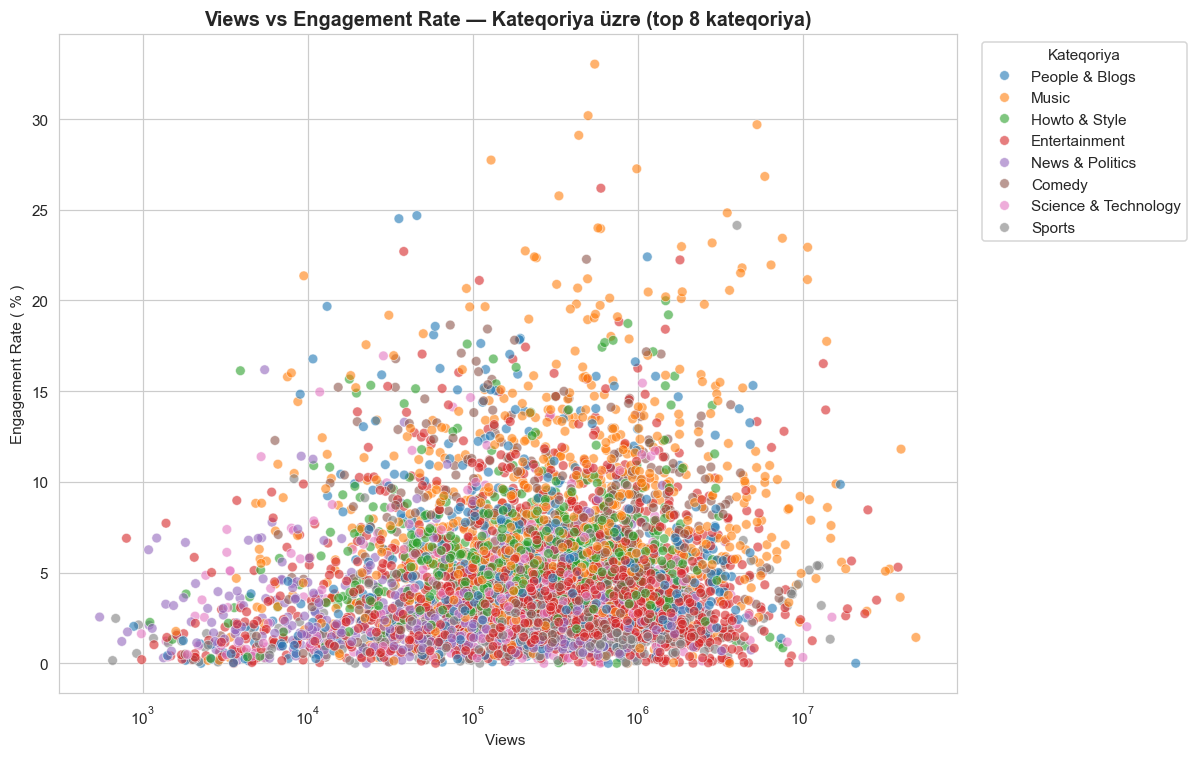

In [19]:
fig, ax = plt.subplots(figsize=(11, 7))
top_categories = df_dedup['category_name'].value_counts().head(8).index
plot_data = df_dedup[df_dedup['category_name'].isin(top_categories)]
sns.scatterplot(data=plot_data, x='views', y='engagement_rate', hue='category_name',
                 alpha=0.6, s=40, palette='tab10', ax=ax)
ax.set_xscale('log')
ax.set_title('Views vs Engagement Rate — Kateqoriya üzrə (top 8 kateqoriya)',
              fontsize=13, fontweight='bold')
ax.set_xlabel('Views ')
ax.set_ylabel('Engagement Rate ( % )')
ax.legend(title='Kateqoriya', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.savefig('views_vs_engagement_scatter.png', dpi=150, bbox_inches='tight')
plt.show()
